In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
from sklearn.metrics import mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity

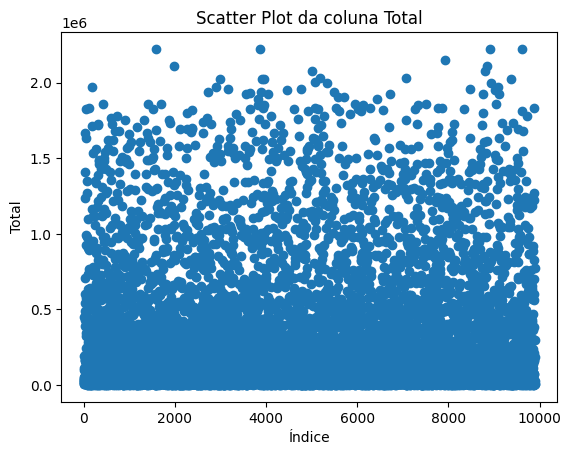

In [40]:
df = pd.read_csv('../datasets/vendas_2023_2024.csv')

x = df.index
y = df['total']
plt.scatter(x, y)

plt.xlabel('Índice')
plt.ylabel('Total')
plt.title('Scatter Plot da coluna Total')

plt.show()

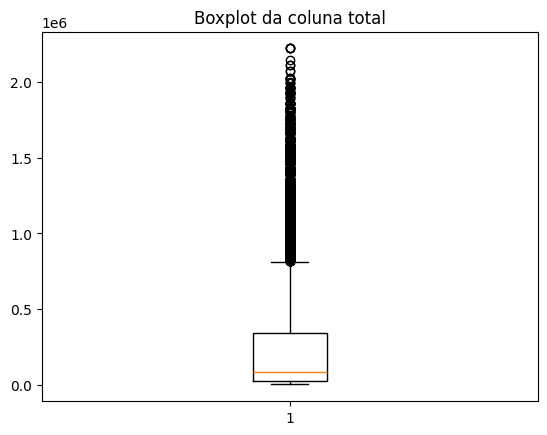

In [47]:
plt.boxplot(df['total'].dropna())
plt.title('Boxplot da coluna total')
plt.show()

Existem valores bem acima da média observada. Isso é mais facilmente observado ao fazer uma análise gráfica da coluna 'total'. Apesar de também ser possível observar valores muito abaixo da média, não considero que esses valores sejam outliers, isso é facilmente observável ao plotar o gráfico de dispersão ou o boxplot. 
Os dados apresentam um problema grande em relação ao formato da data, a coluna está em diversos formatos, sem uma padronização. Além disso, há algumas linhas nulas.
Por conta desses problemas, é necessário uma normalização da coluna data e uma limpeza das linhas nulas.

In [41]:
def rename_column(text: str):
    if text.startswith('elet'):
        return 'eletrônicos'
    elif text.startswith('prop'):
        return 'propulsão'
    elif text.startswith('enc') or text.startswith('anc'):
        return 'ancoragem'

In [42]:
df_products = pd.read_csv('../datasets/produtos_raw.csv')
df_products['code'] = df_products['code'].astype(int)
df_products['price'] = df_products['price'].str.removeprefix('R$ ').astype(float)
df_products['actual_category'] = df_products['actual_category'].str.replace(' ', '').str.lower()
df_products['actual_category'] = df_products['actual_category'].apply(rename_column)
display(len(df_products))
df_products.drop_duplicates(inplace=True)
display(len(df_products))

157

150

7 linhas duplicadas foram removidas

In [43]:
df_products

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,33122.52,1,eletrônicos
1,Transponder Furuno Marlin,13998.15,2,eletrônicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletrônicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletrônicos
4,Piloto Automático Furuno Storm,23669.01,5,eletrônicos
...,...,...,...,...
152,Corrente Delta Vox Ion,495.98,146,ancoragem
153,Corrente Danforth Force Leviathan Impulse,3030.08,147,ancoragem
154,Âncora Delta Force Barracuda Mako,4785.56,148,ancoragem
155,Cabo de Nylon Bruce Core,1163.62,149,ancoragem


In [48]:
with open('../datasets/custos_importacao.json', 'r') as f:
    import_costs = json.load(f)

line = {}
lines = []
columns = ['product_id', 'product_name', 'category', 'start_date', 'usd_price']
for elem in import_costs:
    for i in range(len(elem['historic_data'])):
        line['product_id'] = elem['product_id']
        line['product_name'] = elem['product_name']
        line['category'] = elem['category']
        line['start_date'] = elem['historic_data'][i]['start_date']
        line['usd_price'] = elem['historic_data'][i]['usd_price']
        lines.append(line.copy())

In [49]:
df_import_costs = pd.DataFrame(lines)
df_import_costs['start_date'] = pd.to_datetime(df_import_costs['start_date'], dayfirst=True)
df_import_costs.to_csv('../datasets/custos_importacao.csv', sep=',', index=False,)
df_import_costs

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87
3,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,8772.78
4,1,Transponder AIS Maré Magnum,eletrônicos,2020-01-17,7918.18
...,...,...,...,...,...
1255,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,2023-06-01,326.88
1256,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,2024-01-31,332.26
1257,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,2024-08-29,292.03
1258,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,2024-10-04,300.96


Para a questão 4 o ideal seria termos acesso a uma API do BACEN onde poderíamos cruzar a taxa de câmbio do dia com o dia da venda. Como a questão não especifica isso, decidi usar a taxa média de cada ano.

Taxa de câmbio médio em 2023: 4,9950\
Taxa de câmbio médio em 2024: 5,3895 
[IPEA](https://www.ipeadata.gov.br/ExibeSerie.aspx?serid=31924#:~:text=Table_content:%20header:%20%7C%20Data%20%7C%20Taxa%20de,comercial%20%2D%20venda%20%2D%20m%C3%A9dia:%205%2C5879%20%7C)

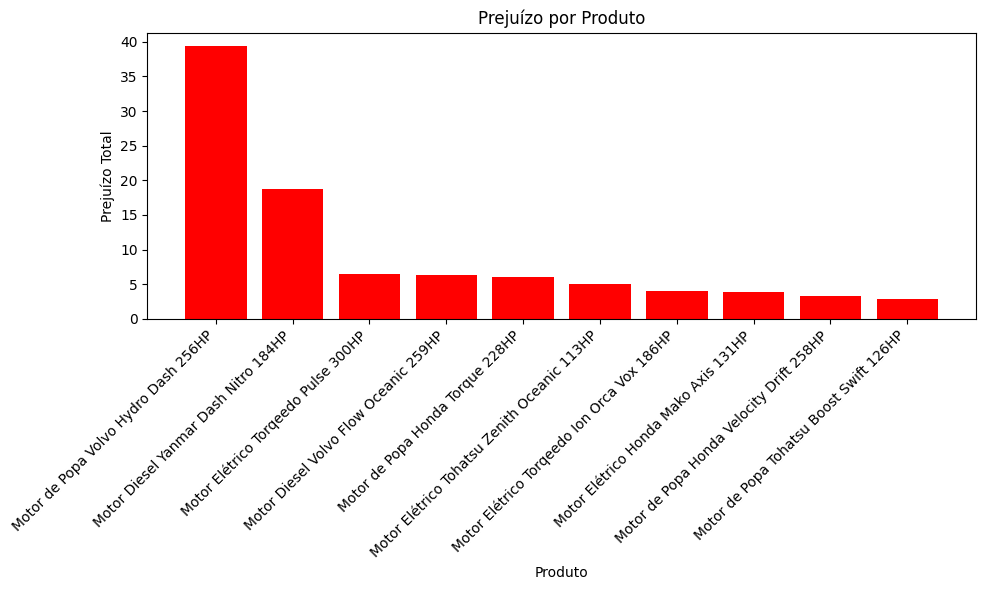

In [60]:
df_prejuizos = pd.read_csv('../datasets/prejuizos.csv')
df_prejuizos = df_prejuizos.sort_values(by='total_loss', ascending=False)
plt.figure(figsize=(10, 6))

plt.bar(df_prejuizos.head(10)['product_name'], df_prejuizos.head(10)['total_loss'] / 1000000, color='red')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Produto')
plt.ylabel('Prejuízo Total')
plt.title('Prejuízo por Produto')


plt.tight_layout()
plt.show()

Para ter uma visualização mais clara, optei por exibir apenas os 10 produtos que deram mais prejuízo. O eixo y está na escala de milhão de reais.

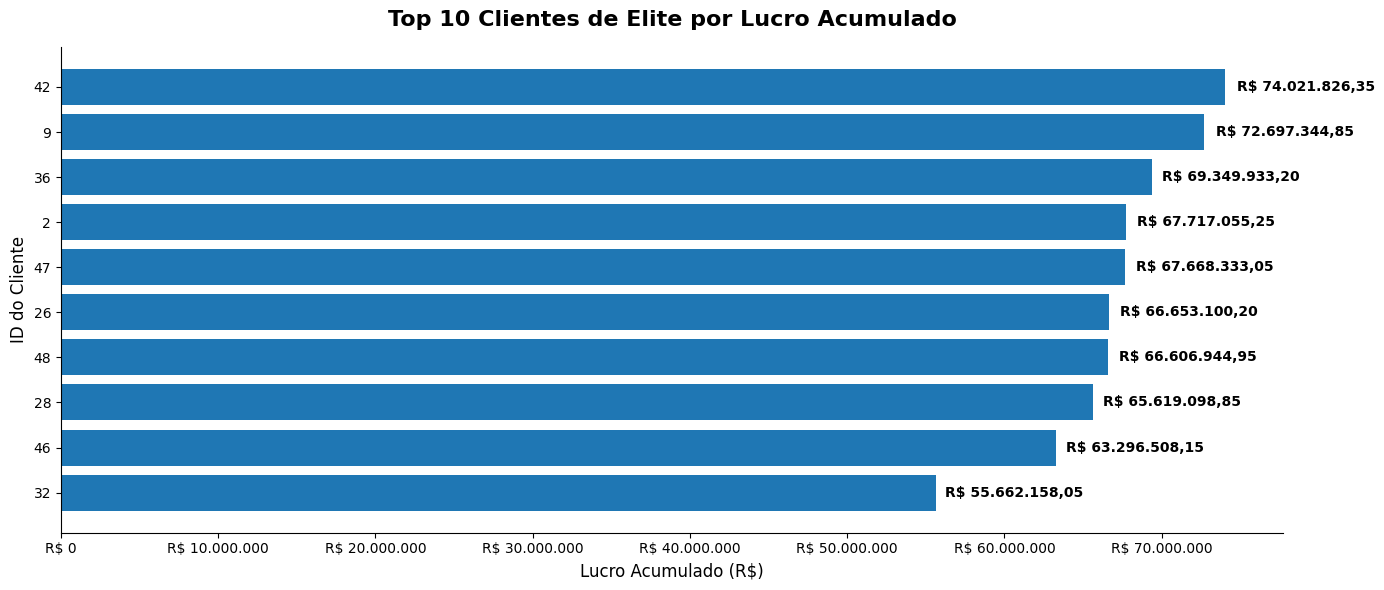

In [64]:
df_top10 = pd.read_csv('../datasets/top10.csv')
df_top10 = df_top10.sort_values(by='total_revenue', ascending=True)
df_top10['id_client'] = df_top10['id_client'].astype(str)
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(df_top10['id_client'], df_top10['total_revenue'])
ax.set_title('Top 10 Clientes de Elite por Lucro Acumulado', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Lucro Acumulado (R$)', fontsize=12)
ax.set_ylabel('ID do Cliente', fontsize=12)
formatter = ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f}'.replace(',', '.'))
ax.xaxis.set_major_formatter(formatter)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(width + (width * 0.01),  
            bar.get_y() + bar.get_height()/2, 
            f'R$ {width:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'), # formato BRL
            ha='left', 
            va='center', 
            fontsize=10, 
            fontweight='bold', 
            color='black')

plt.tight_layout()
plt.show() 

Utilizei lower() para padronizar em minúsculas e expressões regex (~) dentro de um case para agrupar variações de escrita em categorias únicas (ex: “anc”, “enc” → “ancoragem”). Valores não mapeados foram mantidos em minúsculo.
Calculei a diversidade com count(distinct categoria_padronizada) por cliente e apliquei o filtro diversidade_categorias >= 3.
Criei uma CTE (clientes_elite_top10) com os 10 clientes filtrados e usei where id_client in (select ...) para considerar apenas esses clientes na agregação final.

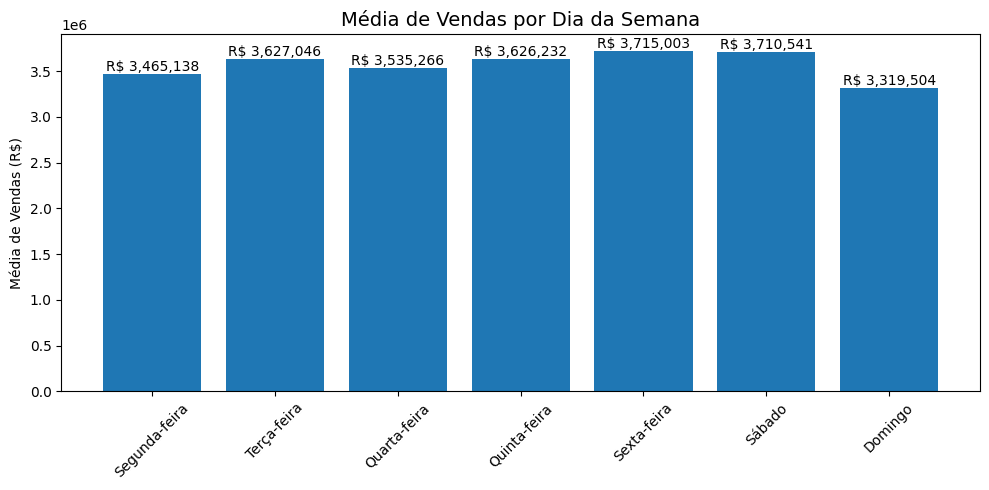

In [ ]:
df_dias = pd.read_csv('../datasets/vendas_dia.csv')
ordem_dias = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
df_dias['dia_da_semana'] = pd.Categorical(df_dias['dia_da_semana'], categories=ordem_dias, ordered=True)
df_dias = df_dias.sort_values('dia_da_semana')
plt.figure(figsize=(10, 5))
bars = plt.bar(df_dias['dia_da_semana'], df_dias['media_vendas_diarias'], color='#1f77b4')
plt.title('Média de Vendas por Dia da Semana', fontsize=14)
plt.ylabel('Média de Vendas (R$)')
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'R$ {yval:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Devemos usar uma dimensão de data, porque a tabela de vendas só contém dias em que houve vendas. A tabela calendário garante a presença de todos os dias no período, incluindo os sem vendas, permitindo análises completas e evitando viés nos cálculos.
Sem a tabela calendário, esses dias seriam ignorados e a média ficaria inflada. Com a tabela calendário, os dias sem venda entram como zero, tornando a média mais precisa e representativa.

In [77]:
df_vendas = pd.read_csv('../datasets/vendas_2023_2024.csv')
df_produtos = pd.read_csv('../datasets/produtos_raw.csv')

df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], format='mixed', dayfirst=True)

nome_produto = 'Motor de Popa Yamaha Evo Dash 155HP'
produto_alvo = df_produtos[df_produtos['name'] == nome_produto]

id_motor = produto_alvo['code'].iloc[0]
df_motor = df_vendas[df_vendas['id_product'] == id_motor]

df_diario = df_motor.groupby(df_motor['sale_date'].dt.date)['qtd'].sum().reset_index()
df_diario['sale_date'] = pd.to_datetime(df_diario['sale_date'])

data_inicio = df_vendas['sale_date'].min()
data_fim = pd.to_datetime('2024-01-31') 
calendario = pd.date_range(start=data_inicio, end=data_fim)

df_completo = pd.DataFrame({'sale_date': calendario})
df_completo = df_completo.merge(df_diario, on='sale_date', how='left').fillna(0)

df_completo['previsao_mm7'] = df_completo['qtd'].shift(1).rolling(window=7, min_periods=1).mean().fillna(0)

df_teste = df_completo[(df_completo['sale_date'] >= '2024-01-01') & (df_completo['sale_date'] <= '2024-01-31')]

mae = mean_absolute_error(df_teste['qtd'], df_teste['previsao_mm7'])

print(f"MAE para Janeiro de 2024: {mae:.2f} unidades de erro em média por dia.")
print(df_teste[['sale_date', 'qtd', 'previsao_mm7']].head(7))


MAE para Janeiro de 2024: 1.00 unidades de erro em média por dia.
     sale_date  qtd  previsao_mm7
365 2024-01-01  0.0           0.0
366 2024-01-02  0.0           0.0
367 2024-01-03  0.0           0.0
368 2024-01-04  0.0           0.0
369 2024-01-05  0.0           0.0
370 2024-01-06  0.0           0.0
371 2024-01-07  0.0           0.0


Para a construção do baseline foi calculado a média móvel das vendas dos últimos 7 dias.
Para prevenir Data Leakage o treino foi limitado a 31/12/2023. As previsões usaram apenas dados de datas anteriores ao dia projetado.
A principal limitação é o fato do método ser puramente reativo. Ele falha ao ignorar a sazonalidade e mudanças bruscas de tendência.

In [ ]:
df_vendas = pd.read_csv('../datasets/vendas_2023_2024.csv')
df_produtos = pd.read_csv('../datasets/produtos_raw.csv')

nome_referencia = 'GPS Garmin Vortex Maré Drift'
produto_alvo = df_produtos[df_produtos['name'] == nome_referencia]
id_gps = produto_alvo['code'].iloc[0]

interacoes = df_vendas[['id_client', 'id_product']].drop_duplicates()
interacoes['comprou'] = 1

matriz_interacao = interacoes.pivot(
    index='id_client', 
    columns='id_product', 
    values='comprou'
).fillna(0)

matriz_produtos = matriz_interacao.T
matriz_similaridade = cosine_similarity(matriz_produtos)

df_similaridade = pd.DataFrame(
    matriz_similaridade, 
    index=matriz_produtos.index, 
    columns=matriz_produtos.index
)

similaridade_gps = df_similaridade[id_gps]

df_ranking = similaridade_gps.reset_index()
df_ranking.columns = ['id_product', 'score_similaridade']

df_ranking = df_ranking[df_ranking['id_product'] != id_gps]

top_5_similares = df_ranking.sort_values(
    by='score_similaridade', 
    ascending=False
).head(5) # type: ignore

top_5_recomendacoes = top_5_similares.merge(
    df_produtos[['code', 'name']], 
    left_on='id_product', 
    right_on='code', 
    how='left'
)

print(f"Produto de Referência: {nome_referencia} (ID: {id_gps})\n")
print("Top 5 Produtos Recomendados:")

for i, row in enumerate(top_5_recomendacoes.itertuples(), start=1):
    print(f"{i}º -> {row.name} (Score: {row.score_similaridade:.4f})")

Produto de Referência: GPS Garmin Vortex Maré Drift (ID: 27)

Top 5 Produtos Recomendados:
1º -> Motor de Popa Volvo Magnum 276HP (Score: 0.8696)
2º -> GPS Furuno Swift Leviathan Poseidon (Score: 0.8680)
3º -> Radar Furuno Swift (Score: 0.8539)
4º -> Transponder AIS Maré Magnum (Score: 0.8500)
5º -> Cabo de Nylon Delta Force Magnum Leviathan (Score: 0.8500)


A matriz é estruturada como uma matriz binária (0/1) Usuário × Produto, onde as linhas representam o id_cliente e as colunas o id_produto. O valor é 1 se o cliente comprou o item ao menos uma vez e 0 caso contrário, ignorando quantidades.
A similaridade representa a afinidade entre itens com base no comportamento compartilhado de compra. Um valor alto indica que os produtos são frequentemente adquiridos pelo mesmo grupo de clientes.
O modelo é incapaz de recomendar produtos novos que ainda não possuem histórico de transações para gerar vetores de comparação.